In [2]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import os
import json

In [42]:
appid_dict = {
    '1622910' : ['Still wakes the deep', 'Horror'],
    '1196590' : ['Resident Evil Village', 'Horror'],
    '3180070' : ['No Im not a Human', 'Horror'],
    '541570'  : ['Sally Face - Episode one', 'Horror'],
    '1929610' : ['Demonologist','Horror'],
    '108710'  : ['Alan_Wake','Horror'],
    '238320'  : ['Outlast','Horror'],
    '506610'  : ["Five Nights at Freddy's: Sister location",'Horror'],
    '214490'  : ['Alien: Isolation','Horror'],
    '594330'  : ['Visage','Horror']
    }

data_path = "data"

rows = []

for filename in os.listdir(data_path):
    if filename.startswith("review_") and filename.endswith(".json"):
        
        # Extract appid from filename
        appid = filename.split("_")[1].split(".")[0]
        
        filepath = os.path.join(data_path, filename)
        
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)
            
            for review in data.get("reviews", {}).values():

                author = review.get("author", {})
                rows.append({
                    "appid": appid,
                    "Game_name" : appid_dict[appid][0],
                    "Genre" : appid_dict[appid][1],
                    "timestamp_created": review.get("timestamp_created"),
                    "voted_up": review.get("voted_up"),
                    "steamid": author.get("steamid"),
                    "review": review.get("review")
                })

                ### FULL JSON TAGS ### if you want to use any other information
                # rows.append({
                #     "appid": appid,
                #     "Game_name" : appid_dict[appid][0],
                #     "Genre" : appid_dict[appid][1],
                #     "steamid": author.get("steamid"),
                #     "personaname": author.get("personaname"),
                #     "persona_status": author.get("persona_status"),
                #     "profile_url": author.get("profile_url"),
                #     "num_games_owned": author.get("num_games_owned"),
                #     "num_reviews": author.get("num_reviews"),
                #     "playtime_forever": author.get("playtime_forever"),
                #     "playtime_last_two_weeks": author.get("playtime_last_two_weeks"),
                #     "playtime_at_review": author.get("playtime_at_review"),
                #     "last_played": author.get("last_played"),
                #     "avatar": author.get("avatar"),

                #     "language": review.get("language"),
                #     "review": review.get("review"),
                #     "timestamp_created": review.get("timestamp_created"),
                #     "timestamp_updated": review.get("timestamp_updated"),
                #     "voted_up": review.get("voted_up"),
                #     "votes_up": review.get("votes_up"),
                #     "votes_funny": review.get("votes_funny"),
                #     "weighted_vote_score": review.get("weighted_vote_score"),
                #     "comment_count": review.get("comment_count"),
                #     "steam_purchase": review.get("steam_purchase"),
                #     "received_for_free": review.get("received_for_free"),
                #     "refunded": review.get("refunded"),
                #     "written_during_early_access": review.get("written_during_early_access"),
                #     "primarily_steam_deck": review.get("primarily_steam_deck"),
                #     "app_release_date": review.get("app_release_date"),
                #     "reactions": review.get("reactions"),
                # })  
# Create dataframe
df = pd.DataFrame(rows)

# Optional: convert timestamp to datetime
df["timestamp_created"] = pd.to_datetime(df["timestamp_created"], unit="s")

print(df.shape)
df.head()

(29641, 7)


,appid,Game_name,Genre,timestamp_created,voted_up,steamid,review
0,108710,Alan_Wake,Horror,2026-05-18 17:09:10,True,76561198715930868,This game runs incredibly well at max settings...
1,108710,Alan_Wake,Horror,2026-05-18 12:40:29,True,76561199196919919,"Nice story, even though bit confusing at the e..."
2,108710,Alan_Wake,Horror,2026-05-17 22:04:36,True,76561198402472807,"Overall, Alan Wake is a solid title, But falls..."
3,108710,Alan_Wake,Horror,2026-05-17 20:06:58,True,76561198739355493,pretty much a running simulator but a damn goo...
4,108710,Alan_Wake,Horror,2026-05-17 19:17:40,True,76561198101043758,Fun game but not for everyone. I think the gam...


In [44]:
df.appid.value_counts()

appid
3180070    8815
1196590    7906
238320     2930
1622910    2557
108710     2385
214490     2093
541570     1264
1929610     885
506610      595
594330      211
Name: count, dtype: int64

In [45]:
def clean_text(text):
    text = re.sub(r'\[.*?\]', ' ', text)      
    text = re.sub(r'http\S+|www\.\S+', ' ', text) 
    text = re.sub(r'\s+', ' ', text)     
    return text.strip()

df['Clean'] = df['review'].apply(clean_text)

In [46]:
df.head()

,appid,Game_name,Genre,timestamp_created,voted_up,steamid,review,Clean
0,108710,Alan_Wake,Horror,2026-05-18 17:09:10,True,76561198715930868,This game runs incredibly well at max settings...,This game runs incredibly well at max settings...
1,108710,Alan_Wake,Horror,2026-05-18 12:40:29,True,76561199196919919,"Nice story, even though bit confusing at the e...","Nice story, even though bit confusing at the e..."
2,108710,Alan_Wake,Horror,2026-05-17 22:04:36,True,76561198402472807,"Overall, Alan Wake is a solid title, But falls...","Overall, Alan Wake is a solid title, But falls..."
3,108710,Alan_Wake,Horror,2026-05-17 20:06:58,True,76561198739355493,pretty much a running simulator but a damn goo...,pretty much a running simulator but a damn goo...
4,108710,Alan_Wake,Horror,2026-05-17 19:17:40,True,76561198101043758,Fun game but not for everyone. I think the gam...,Fun game but not for everyone. I think the gam...


In [47]:
# Make sure timestamp is datetime
df['timestamp_created'] = pd.to_datetime(df['timestamp_created'])
df['date'] = df['timestamp_created'].dt.date

In [48]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sentAnalyser = SentimentIntensityAnalyzer()

def vader_scores(text):
    s = sentAnalyser.polarity_scores(text)
    return pd.Series([s['neg'], s['neu'], s['pos'], s['compound']])

df[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']] = \
    df['Clean'].apply(vader_scores)

# Convert compound score to a label
def label(c):
    if c >= 0.05:  return 'positive'
    if c <= -0.05: return 'negative'
    return 'neutral'

df['vader_label'] = df['vader_compound'].apply(label)

In [49]:
df.head()

,appid,Game_name,Genre,timestamp_created,voted_up,steamid,review,Clean,date,vader_neg,vader_neu,vader_pos,vader_compound,vader_label
0,108710,Alan_Wake,Horror,2026-05-18 17:09:10,True,76561198715930868,This game runs incredibly well at max settings...,This game runs incredibly well at max settings...,2026-05-18,0.000,0.856,0.144,0.3989,positive
1,108710,Alan_Wake,Horror,2026-05-18 12:40:29,True,76561199196919919,"Nice story, even though bit confusing at the e...","Nice story, even though bit confusing at the e...",2026-05-18,0.161,0.696,0.144,-0.3535,negative
2,108710,Alan_Wake,Horror,2026-05-17 22:04:36,True,76561198402472807,"Overall, Alan Wake is a solid title, But falls...","Overall, Alan Wake is a solid title, But falls...",2026-05-17,0.128,0.730,0.142,0.3604,positive
3,108710,Alan_Wake,Horror,2026-05-17 20:06:58,True,76561198739355493,pretty much a running simulator but a damn goo...,pretty much a running simulator but a damn goo...,2026-05-17,0.150,0.380,0.470,0.8225,positive
4,108710,Alan_Wake,Horror,2026-05-17 19:17:40,True,76561198101043758,Fun game but not for everyone. I think the gam...,Fun game but not for everyone. I think the gam...,2026-05-17,0.236,0.548,0.217,-0.4096,negative


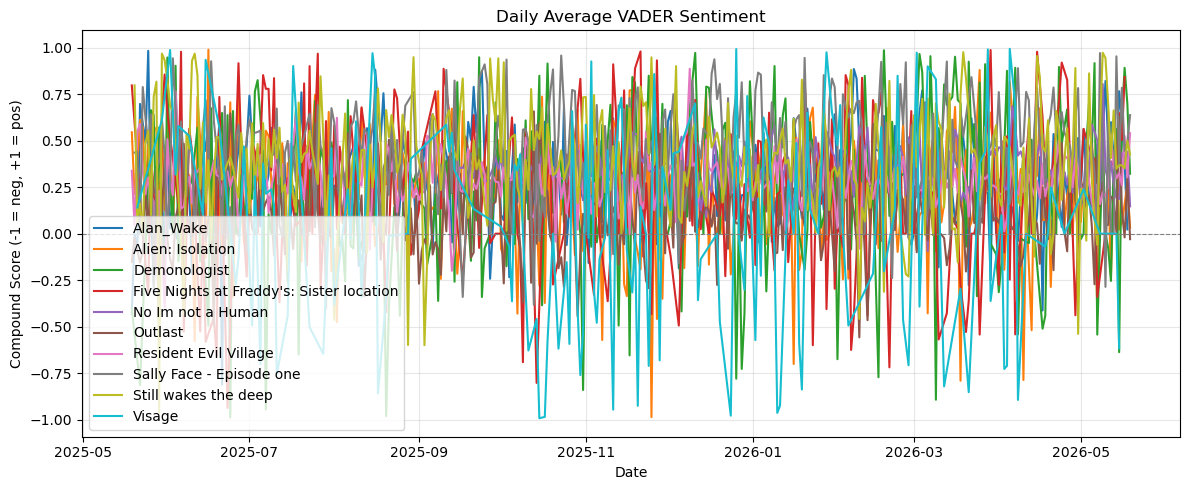

In [54]:
daily = (df.groupby(['Game_name', 'date'])['vader_compound']
           .mean()
           .reset_index())

plt.figure(figsize=(12, 5))
for Game_name, g in daily.groupby('Game_name'):
    plt.plot(g['date'], g['vader_compound'], label=f'{Game_name}')
    

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Daily Average VADER Sentiment')
plt.xlabel('Date')
plt.ylabel('Compound Score (-1 = neg, +1 = pos)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
for game, g in daily.groupby('Game_name'):
    print(game)

Alan_Wake
Alien: Isolation
Demonologist
Five Nights at Freddy's: Sister location
No Im not a Human
Outlast
Resident Evil Village
Sally Face - Episode one
Still wakes the deep
Visage


In [59]:
vaderSentimentSeries = pd.DataFrame(df.loc[df['Genre'] == 'Horror'], columns=['timestamp_created','vader_compound'])
vaderSentimentSeries

,timestamp_created,vader_compound
0,2026-05-18 17:09:10,0.3989
1,2026-05-18 12:40:29,-0.3535
2,2026-05-17 22:04:36,0.3604
3,2026-05-17 20:06:58,0.8225
4,2026-05-17 19:17:40,-0.4096
...,...,...
29636,2025-06-05 06:28:52,0.5780
29637,2025-06-04 07:53:32,0.3174
29638,2025-06-02 20:39:24,0.9869
29639,2025-05-30 22:27:25,0.6107


<Axes: xlabel='timestamp_created'>

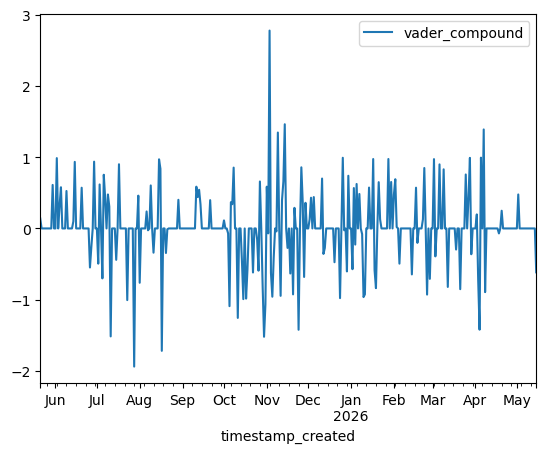

In [68]:
vaderSentimentSeries = pd.DataFrame(df.loc[df['Game_name'] == 'Visage'], columns=['timestamp_created','vader_compound'])

vaderSentimentSeries.set_index('timestamp_created', inplace=True)
vaderSentimentSeries[['vader_compound']] = vaderSentimentSeries[['vader_compound']].apply(pd.to_numeric)

vaderSentimentWeekly = vaderSentimentSeries.resample('D').sum()

vaderSentimentWeekly.plot()

<Axes: xlabel='timestamp_created'>

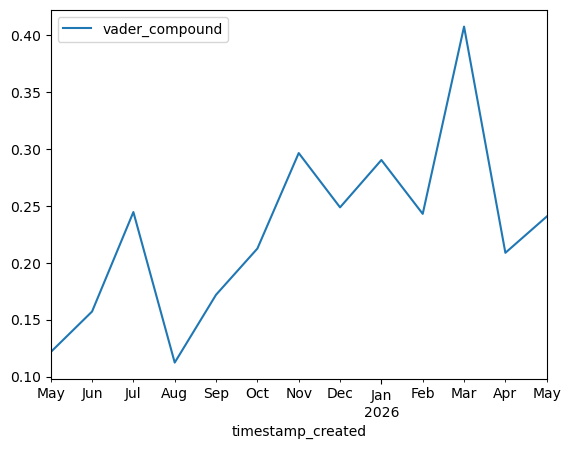

In [75]:
vaderSentimentSeries = pd.DataFrame(df.loc[df['appid'] == '1929610'], columns=['timestamp_created','vader_compound'])

vaderSentimentSeries.set_index('timestamp_created', inplace=True)
vaderSentimentSeries[['vader_compound']] = vaderSentimentSeries[['vader_compound']].apply(pd.to_numeric)

vaderSentimentWeekly = vaderSentimentSeries.resample('ME').mean()

vaderSentimentWeekly.plot()